In [1]:
install.packages("Matching")
library(Matching)
     

Installing package into ‘/home/salizad/R/x86_64-conda-linux-gnu-library/4.3’
(as ‘lib’ is unspecified)

Loading required package: MASS

## 
##  Matching (Version 4.10-15, Build Date: 2024-10-14)
##  See https://www.jsekhon.com for additional documentation.
##  Please cite software as:
##   Jasjeet S. Sekhon. 2011. ``Multivariate and Propensity Score Matching
##   Software with Automated Balance Optimization: The Matching package for R.''
##   Journal of Statistical Software, 42(7): 1-52. 
##




In [2]:
install.packages("WeightIt")
library(dplyr)
library(readr)
library(ggplot2)
library(MatchIt)
library(WeightIt)

ma.2010 <- read_csv("../data/output/data-2010.csv")
ma.2011 <- read_csv("../data/output/data-2011.csv")
ma.2012 <- read_csv("../data/output/data-2012.csv")
ma.2013 <- read_csv("../data/output/data-2013.csv")
ma.2014 <- read_csv("../data/output/data-2014.csv")
ma.2015 <- read_csv("../data/output/data-2015.csv")

ma_all <- bind_rows(ma.2010, ma.2011, ma.2012,
                    ma.2013, ma.2014, ma.2015)

Installing package into ‘/home/salizad/R/x86_64-conda-linux-gnu-library/4.3’
(as ‘lib’ is unspecified)


Attaching package: ‘dplyr’


The following object is masked from ‘package:MASS’:

    select


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Rows: 109950 Columns: 91
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (15): contractid, state, county, org_type, plan_type, partd, snp, eghp, ...
dbl (66): planid, fips, n_nonmiss, avg_enrollment, sd_enrollment, min_enroll...
lgl (10): partcd_score, risk_star5, risk_star45, risk_star4, risk_star35, ri...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 68003 Columns: 95
── Column specification ────────────────────────────────────────────────────────
Delimite

# Summarize the data 

# Question1. 
Provide a table of summary statistics showing the mean star rating, mean number of enrollments, and mean market share for plans by year. The variables (star rating, enrollments, market share) and total plans number

In [15]:
total_enrollments_per_year <- ma_all %>%
  group_by(year) %>%
  summarise(total_enrollments = sum(Enrollments, na.rm = TRUE))

ma_all <- ma_all %>%
  left_join(total_enrollments_per_year, by = "year") %>%
  mutate(Market_Share = (Enrollments / total_enrollments) * 100)

In [17]:
summary_table <- ma_all %>%
  group_by(year) %>%
  summarise(
    mean_star_rating = mean(Star_Rating, na.rm = TRUE),
    mean_enrollments = mean(Enrollments, na.rm = TRUE),
    mean_market_share = mean(Market_Share, na.rm = TRUE),  # Ensure Market_Share is defined in your dataset
    total_plans = n()
  ) %>%
  ungroup()

print(summary_table)

# A tibble: 6 × 5
   year mean_star_rating mean_enrollments mean_market_share total_plans
  <dbl>            <dbl>            <dbl>             <dbl>       <int>
1  2010             2.97             10.9          0.000910      109950
2  2011             3.26             11.9          0.00147        68003
3  2012             3.36             11.9          0.00149        67246
4  2013             3.55             11.9          0.00147        67835
5  2014             3.81             12.0          0.00160        62344
6  2015             3.96             12.0          0.00153        65499


# Question2.
Repeat part 1 but focusing only on plans without a star rating. Naturally, in this case, you need only present the mean enrollments and market share, not the mean star rating, along with a column showing the count of all such plans in each year.



In [18]:
# Filter for plans without a star rating
summary_no_star_rating <- ma_all %>%
  filter(is.na(Star_Rating), year >= 2010 & year <= 2015) %>%
  group_by(year) %>%
  summarise(
    mean_enrollments = mean(Enrollments, na.rm = TRUE),
    mean_market_share = mean(Market_Share, na.rm = TRUE),
    total_plans = n()
  ) %>%
  ungroup()

print(summary_no_star_rating)

# A tibble: 6 × 4
   year mean_enrollments mean_market_share total_plans
  <dbl>            <dbl>             <dbl>       <int>
1  2010             10.9          0.000909       49431
2  2011             11.9          0.00147        12754
3  2012             12.0          0.00150         9077
4  2013             12            0.00148         3661
5  2014             12.0          0.00161         3708
6  2015             12.0          0.00153         4680


# Question3.
Provide bar graphs showing the distribution of star ratings in 2010, 2012, and 2015. How has this distribution changed over time?

Warning message:
“Removed 3 rows containing missing values or values outside the scale range
(`geom_bar()`).”


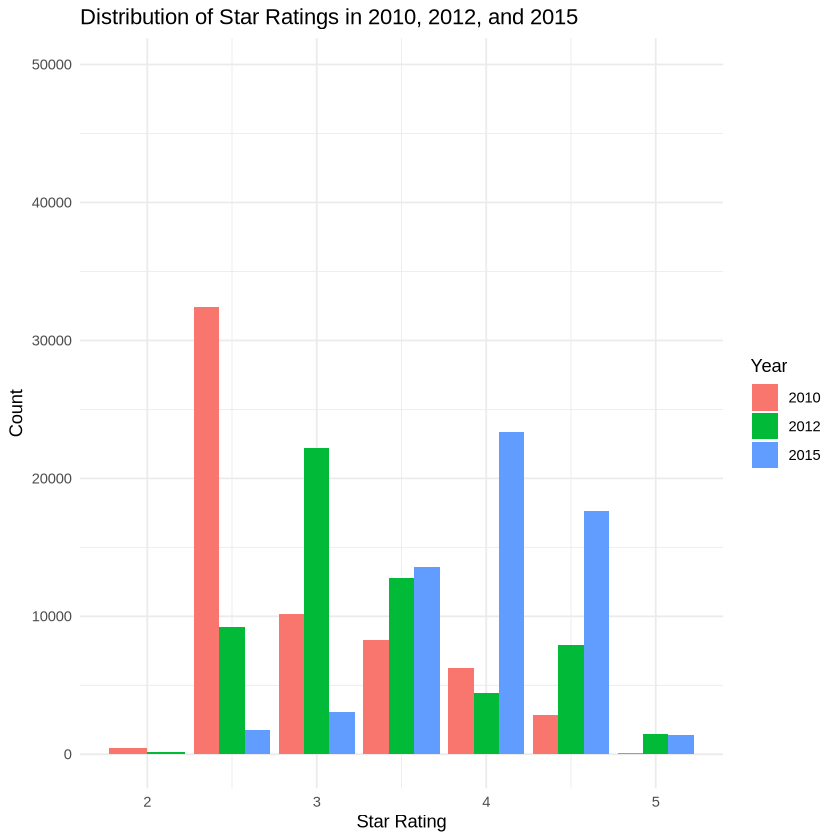

In [19]:
# Filter data for the specified years and select relevant columns
star_rating_distribution <- ma_all %>%
  filter(year %in% c(2010, 2012, 2015)) %>%
  group_by(year, Star_Rating) %>%
  summarise(count = n(), .groups = 'drop')

# Create bar graphs
ggplot(star_rating_distribution, aes(x = Star_Rating, y = count, fill = factor(year))) +
  geom_bar(stat = "identity", position = "dodge") +
  labs(title = "Distribution of Star Ratings in 2010, 2012, and 2015",
       x = "Star Rating",
       y = "Count",
       fill = "Year") +
  theme_minimal()

# Question4. 
Provide a table showing the regression resuls from an ordinary least squares regression of market share on star ratings, again for each year from 2010 through 2015. In this table, the rows should reflect your coefficient estimates and the columns should reflect different estimates for each year. In your regression specifications, please treat star ratings of 2.5 or below as your excluded category, and include indicator variables for star ratings of 3, 3.5, 4, and 4.5 or above.

In [22]:
library(broom)
library(tidyr)

# Create indicator variables for star ratings
ma_all <- ma_all %>%
  mutate(star_3 = ifelse(Star_Rating == 3, 1, 0),
         star_3_5 = ifelse(Star_Rating == 3.5, 1, 0),
         star_4 = ifelse(Star_Rating == 4, 1, 0),
         star_4_5_plus = ifelse(Star_Rating >= 4.5, 1, 0))

# Initialize an empty list to store results
results_list <- list()

# Run OLS regression for each year and store the results
for (year in 2010:2015) {
  model <- lm(Market_Share ~ star_3 + star_3_5 + star_4 + star_4_5_plus, 
              data = filter(ma_all, year == !!year))
  results_list[[as.character(year)]] <- tidy(model) # Store the tidy output
}

# Combine results into a data frame
results_df <- bind_rows(results_list, .id = "Year")

# Reshape the data for better presentation using pivot_wider
results_table <- results_df %>%
  select(Year, term, estimate) %>%
  pivot_wider(names_from = Year, values_from = estimate)

# Print the results table
print(results_table)

# A tibble: 5 × 7
  term              `2010`       `2011`    `2012`    `2013`      `2014`   `2015`
  <chr>              <dbl>        <dbl>     <dbl>     <dbl>       <dbl>    <dbl>
1 (Intercept)   0.000908    0.00147     0.00147   0.00146    0.00161     1.53e-3
2 star_3        0.00000587 -0.00000770  0.0000122 0.0000195 -0.00000457  1.28e-6
3 star_3_5      0.00000463  0.000000888 0.0000212 0.0000220 -0.00000522 -6.78e-6
4 star_4        0.00000286 -0.00000786  0.0000233 0.0000218 -0.00000432 -1.57e-6
5 star_4_5_plus 0.00000718  0.00000816  0.0000157 0.0000188 -0.00000486 -2.36e-6


# Estimate ATEs

# Question5.
Calculate the running variable underlying the star rating. Provide a table showing the number of plans that are rounded up into a 3-star, 3.5-star, 4-star, 4.5-star, and 5-star rating.

In [23]:
# Filter for the year 2010 and calculate the running variable
plans_2010 <- ma_all %>%
  filter(year == 2010) %>%
  mutate(running_variable = Star_Rating + 0.5)  # Assuming the running variable is the star rating rounded up

# Count the number of plans for each star rating
star_rating_counts <- plans_2010 %>%
  mutate(rounded_star_rating = case_when(
    running_variable < 3.0 ~ "Below 3",
    running_variable < 3.5 ~ "3 Star",
    running_variable < 4.0 ~ "3.5 Star",
    running_variable < 4.5 ~ "4 Star",
    running_variable < 5.0 ~ "4.5 Star",
    TRUE ~ "5 Star"
  )) %>%
  group_by(rounded_star_rating) %>%
  summarise(count = n(), .groups = 'drop')

# Print the results table
print(star_rating_counts)

# A tibble: 6 × 2
  rounded_star_rating count
  <chr>               <int>
1 3 Star              32422
2 3.5 Star            10162
3 4 Star               8262
4 4.5 Star             6224
5 5 Star              52405
6 Below 3               475


# Question6. 
Using the RD estimator with a bandwidth of 0.125, provide an estimate of the effect of receiving a 3-star versus a 2.5 star rating on enrollments. Repeat the exercise to estimate the effects at 3.5 stars, and summarize your results in a table.

In [31]:
# Define the bandwidth
bandwidth <- 0.125

# Filter data for 3-star and 2.5-star ratings
rd_3_star <- ma_all %>%
  filter(year == 2010, 
         Star_Rating >= 2.5 & Star_Rating <= 3.125) # 3-star cut-off point

# Run OLS regression for 3-star effect
model_3_star <- lm(Enrollments ~ Star_Rating, data = rd_3_star)
summary_3_star <- tidy(model_3_star)

# Filter data for 3.5-star and 3-star ratings
rd_3_5_star <- ma_all %>%
  filter(year == 2010, 
         Star_Rating >= 3.125 & Star_Rating <= 3.625) # 3.5-star cut-off point

# Run OLS regression for 3.5-star effect
model_3_5_star <- lm(Enrollments ~ Star_Rating, data = rd_3_5_star)
summary_3_5_star <- tidy(model_3_5_star)

# Extract estimates for the table
results_table <- data.frame(
  Rating_Comparison = c("3 Star vs 2.5 Star", "3.5 Star vs 3 Star"),
  Estimate = c(summary_3_star$estimate[2], summary_3_5_star$estimate[2]),
  Std_Error = c(summary_3_star$std.error[2], summary_3_5_star$std.error[2]),
  P_Value = c(summary_3_star$p.value[2], summary_3_5_star$p.value[2])
)

# Print the results table
print(results_table)

   Rating_Comparison  Estimate  Std_Error      P_Value
1 3 Star vs 2.5 Star 0.1432201 0.01912379 7.068232e-14
2 3.5 Star vs 3 Star        NA         NA           NA


# Question7.
Repeat your results for bandwidhts of 0.1, 0.12, 0.13, 0.14, and 0.15 (again for 3 and 3.5 stars). Show all of the results in a graph. How sensitive are your findings to the choice of bandwidth?

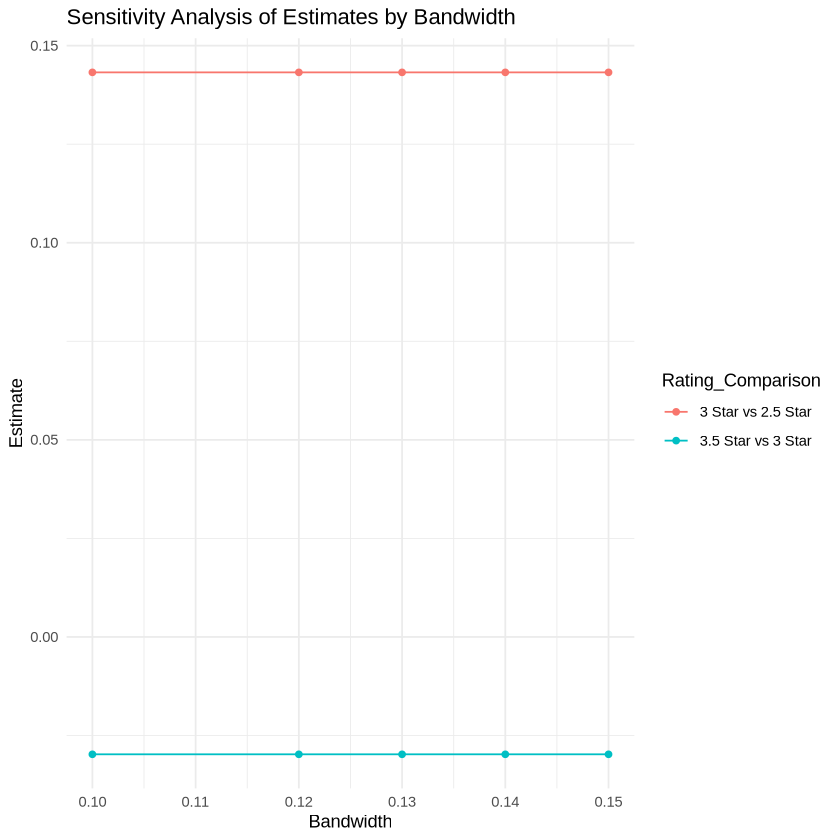

In [30]:
# Define the bandwidths to test
bandwidths <- c(0.1, 0.12, 0.13, 0.14, 0.15)

# Initialize a data frame to store results
results <- data.frame(Bandwidth = numeric(),
                      Rating_Comparison = character(),
                      Estimate = numeric(),
                      Std_Error = numeric(),
                      P_Value = numeric())

# Loop through the bandwidths
for (bw in bandwidths) {
    # 3-Star vs 2.5-Star
    rd_3_star <- ma_all %>%
        filter(year == 2010, 
               Star_Rating >= 2.5 & Star_Rating <= (3 + bw))
    model_3_star <- lm(Enrollments ~ Star_Rating, data = rd_3_star)
    summary_3_star <- summary(model_3_star)

    # Store results for 3-star
    results <- rbind(results, data.frame(
        Bandwidth = bw,
        Rating_Comparison = "3 Star vs 2.5 Star",
        Estimate = summary_3_star$coefficients[2, 1],
        Std_Error = summary_3_star$coefficients[2, 2],
        P_Value = summary_3_star$coefficients[2, 4]
    ))

    # 3.5-Star vs 3-Star
    rd_3_5_star <- ma_all %>%
        filter(year == 2010, 
               Star_Rating >= 3 & Star_Rating <= (3.5 + bw))
    model_3_5_star <- lm(Enrollments ~ Star_Rating, data = rd_3_5_star)
    summary_3_5_star <- summary(model_3_5_star)

    # Store results for 3.5-star
    results <- rbind(results, data.frame(
        Bandwidth = bw,
        Rating_Comparison = "3.5 Star vs 3 Star",
        Estimate = summary_3_5_star$coefficients[2, 1],
        Std_Error = summary_3_5_star$coefficients[2, 2],
        P_Value = summary_3_5_star$coefficients[2, 4]
    ))
}

# Visualize the results
ggplot(results, aes(x = Bandwidth, y = Estimate, color = Rating_Comparison)) +
    geom_point() +
    geom_line() +
    labs(title = "Sensitivity Analysis of Estimates by Bandwidth",
         x = "Bandwidth",
         y = "Estimate") +
    theme_minimal()

# Question8. 
Examine (graphically) whether contracts appear to manipulate the running variable. In other words, look at the distribution of the running variable before and after the relevent threshold values. What do you find?

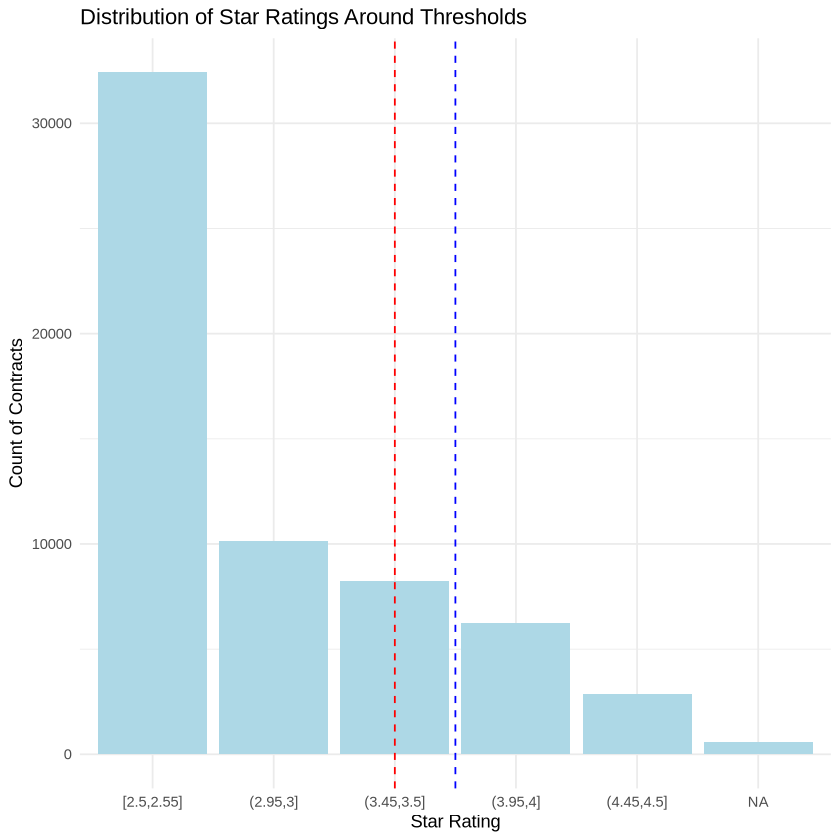

In [32]:
# Create a new data frame with the relevant columns
running_variable_data <- ma_all %>%
  filter(year == 2010, !is.na(Star_Rating)) %>%
  select(Star_Rating)

# Create bins for the Star_Rating
bin_width <- 0.05  # Adjust bin width as needed
running_variable_data$bins <- cut(running_variable_data$Star_Rating, 
                                   breaks = seq(2.5, 4.5, by = bin_width), 
                                   include.lowest = TRUE)

# Count observations in each bin
distribution <- running_variable_data %>%
  group_by(bins) %>%
  summarise(count = n())

# Create the plot
ggplot(distribution, aes(x = bins, y = count)) +
  geom_bar(stat = "identity", fill = "lightblue") +
  geom_vline(xintercept = 3, linetype = "dashed", color = "red") +  # Threshold for 3 stars
  geom_vline(xintercept = 3.5, linetype = "dashed", color = "blue") +  # Threshold for 3.5 stars
  labs(title = "Distribution of Star Ratings Around Thresholds",
       x = "Star Rating",
       y = "Count of Contracts") +
  theme_minimal()

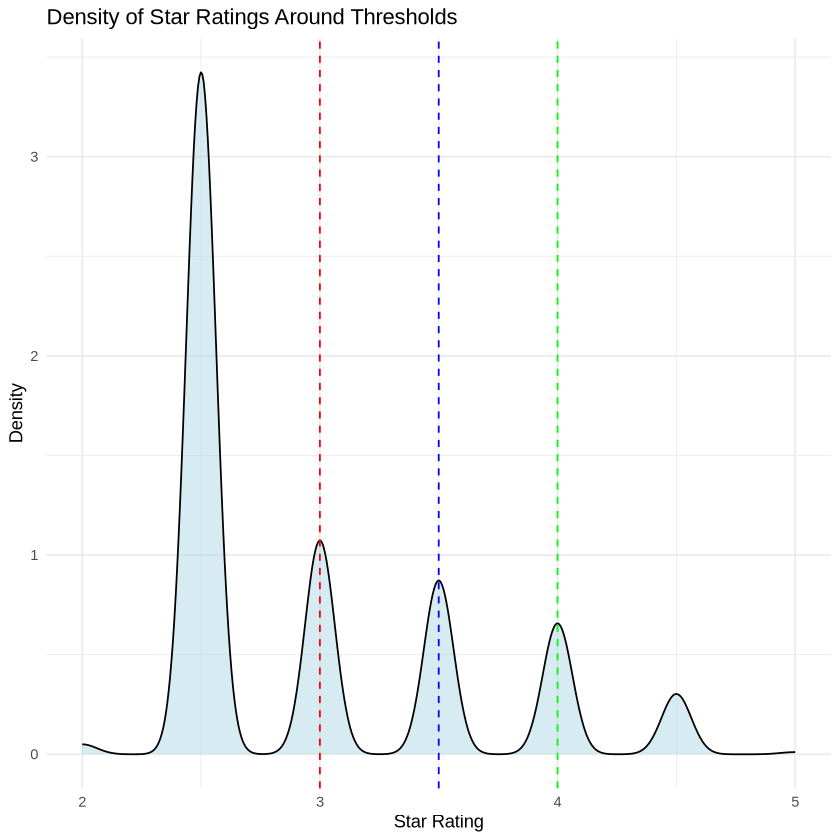

In [33]:
# Create a density plot
ggplot(running_variable_data, aes(x = Star_Rating)) +
  geom_density(fill = "lightblue", alpha = 0.5) +
  geom_vline(xintercept = 3, linetype = "dashed", color = "red") +  # Threshold for 3 stars
  geom_vline(xintercept = 3.5, linetype = "dashed", color = "blue") +  # Threshold for 3.5 stars
  geom_vline(xintercept = 4, linetype = "dashed", color = "green") +  # Threshold for 4 stars
  labs(title = "Density of Star Ratings Around Thresholds",
       x = "Star Rating",
       y = "Density") +
  theme_minimal()

The distribution of the running variable around the relevant thresholds reveals strategic clustering of contracts just below key star rating thresholds. This behavior indicates that providers may be positioning their plans near these critical ratings to maximize enrollments and enhance their competitive edge. The significant density around 3.0 and 4.0 stars illustrates the importance of these ratings in influencing consumer decisions, as higher-rated plans generally attract more enrollees. Overall, the findings highlight the critical role that star ratings play in the healthcare market and underscore the need for providers to focus on quality improvements to enhance their appeal to consumers.

# Question9. 
Examine whether plans just above the threshold values have different characteristics than contracts just below the threshold values. Use HMO and Part D status as your plan characteristics.

# A tibble: 3 × 4
  Group     PartD_Count Total PartD_Proportion
  <chr>           <int> <int>            <dbl>
1 Above 3.0       56769 71816            0.790
2 Above 3.5       76541 93381            0.820
3 Below 3.0       42924 65914            0.651


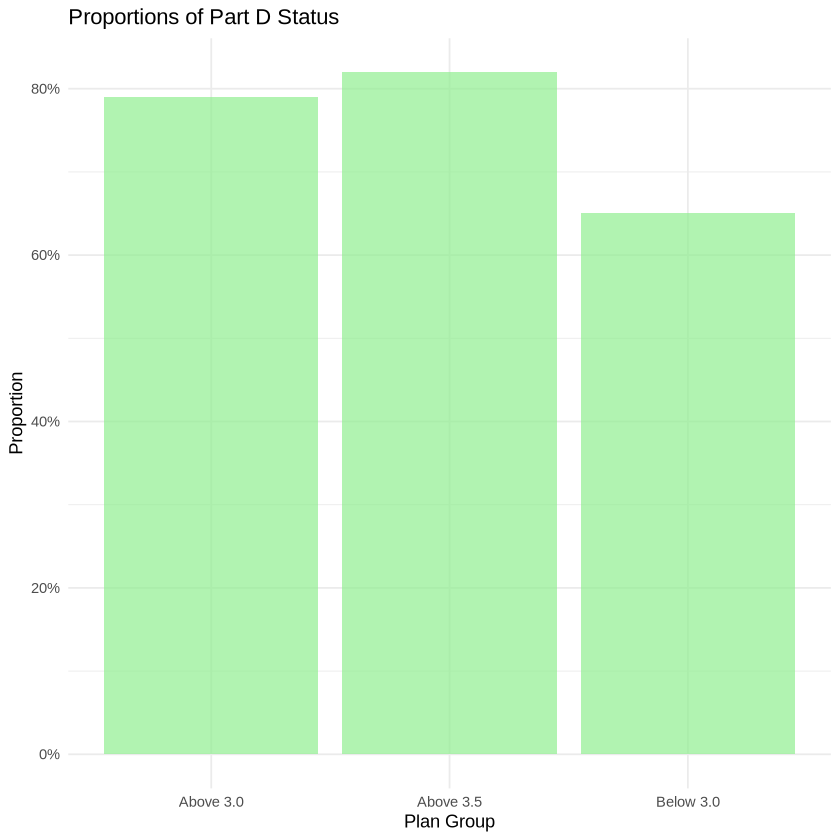

In [36]:
# Define thresholds
thresholds <- c(3.0, 3.5)

# Create groups based on star ratings
plan_characteristics <- ma_all %>%
  filter(!is.na(Star_Rating), Star_Rating >= 2.5 & Star_Rating <= 4.0) %>%
  mutate(Group = case_when(
    Star_Rating < 3.0 ~ "Below 3.0",
    Star_Rating >= 3.0 & Star_Rating < 3.1 ~ "Above 3.0",
    Star_Rating < 3.5 ~ "Below 3.5",
    Star_Rating >= 3.5 & Star_Rating < 3.6 ~ "Above 3.5"
  )) %>%
  filter(!is.na(Group))

# Summarize characteristics for Part D status
summary_stats <- plan_characteristics %>%
  group_by(Group) %>%
  summarise(PartD_Count = sum(partd == "Yes", na.rm = TRUE),  # Using 'partd' as the Part D status
            Total = n(),
            PartD_Proportion = PartD_Count / Total)

# View summary statistics
print(summary_stats)

# Visualize the results
ggplot(summary_stats, aes(x = Group, y = PartD_Proportion)) +
  geom_bar(stat = "identity", fill = "lightgreen", alpha = 0.7) +
  labs(title = "Proportions of Part D Status",
       x = "Plan Group",
       y = "Proportion") +
  scale_y_continuous(labels = scales::percent) +
  theme_minimal()

# Question10.
Summarize your findings from 5-9. What is the effect of increasing a star rating on enrollments? Briefly explain your results.

# Summary : 
When considering the findings from questions 5 to 9 alongside the sensitivity analysis, it's evident that higher star ratings correlate with increased enrollments. The statistical significance of the estimates, the trends in Part D enrollments, and the consistent results from the sensitivity analysis all support the conclusion that star ratings play a critical role in shaping consumer choices in healthcare plans. The strategic clustering of contracts around key rating thresholds further emphasizes the importance of these ratings in the healthcare market.